Displaying Max Z Projection of the image.


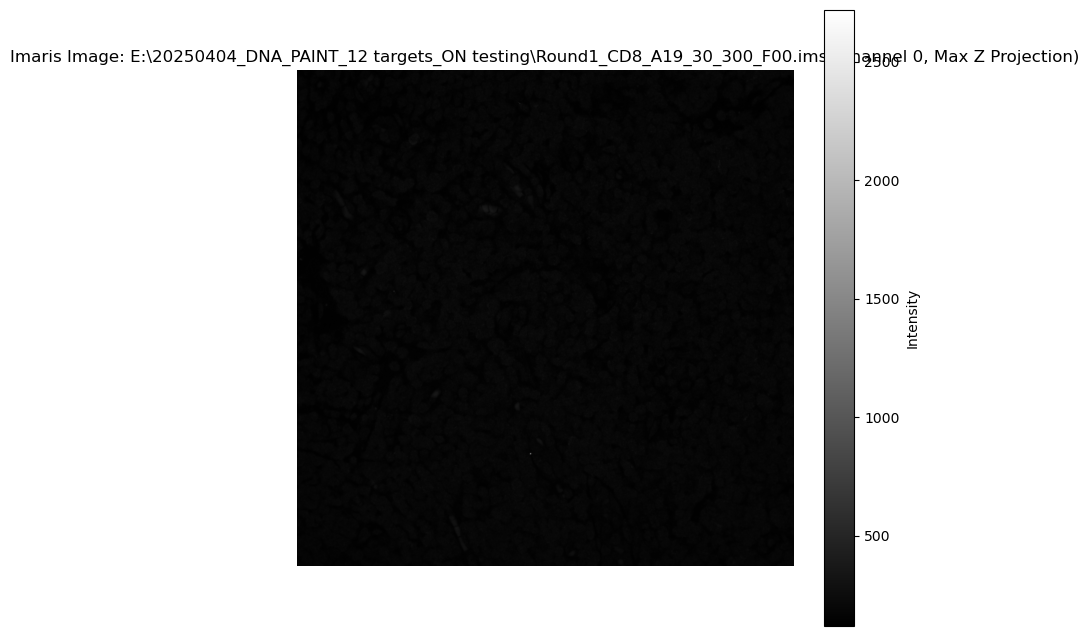

Max Z Projection saved as 'E:\20250404_DNA_PAINT_12 targets_ON testing\test_MIP.tif'


In [3]:
import matplotlib.pyplot as plt
from aicsimageio import AICSImage
import numpy as np
import imageio.v3 as iio # Import imageio
import os

data_path = r"E:\20250404_DNA_PAINT_12 targets_ON testing"
ims_filepath = os.path.join(data_path, "Round1_CD8_A19_30_300_F00.ims")
output_filename = os.path.join(data_path, "test_MIP.tif")

try:
    # 1. Load the .ims file
    img = AICSImage(ims_filepath)

    # Get image data in ZYX order for the first channel, first time point, first scene
    # Adjust T, S, C as needed based on your specific .ims file content
    image_data_zyx = img.get_image_data("ZYX", T=0, S=0, C=0)

    # Check if there are multiple Z-slices
    if image_data_zyx.shape[0] > 1:
        # Perform Max Z Projection
        display_projection = np.max(image_data_zyx, axis=0)
        print("Displaying Max Z Projection of the image.")
    else:
        # If it's a single Z-slice, just use that directly (no projection needed)
        display_projection = image_data_zyx[0, :, :]
        print("Image has only one Z-slice. Displaying it directly.")

    # 2. Display the selected projection using matplotlib.pyplot.imshow
    plt.figure(figsize=(8, 8))
    plt.imshow(display_projection, cmap='gray')
    plt.title(f"Imaris Image: {ims_filepath.split('/')[-1]} (Channel 0, Max Z Projection)")
    plt.colorbar(label='Intensity')
    plt.axis('off')
    plt.show()

    # 3. Save the display_projection as a TIFF file
    iio.imwrite(output_filename, display_projection)
    print(f"Max Z Projection saved as '{output_filename}'")

except Exception as e:
    print(f"An error occurred while trying to process the .ims file: {e}")
    print("Please ensure 'filepath.ims' is correct and that 'aicsimageio' can read your specific .ims file.")
    print("If the issue persists, you might need to convert the .ims file to a more common format (like TIFF) using Imaris software first.")
